# Atividade PBL - 1º Bimestre

**Disciplina:** Processamento de Imagens - CC8NA
**Prof.:** Claudio M. S. Coutinho
**Data:** 18/09/2026

**Integrantes:**
- Davi Tuma Furtado
- Luís Cláudio Rodrigues Sarmento
- Pedro Henrique Carneiro da Silva

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [8]:
arquivos_upload = files.upload()

Saving imagem_01.png to imagem_01.png
Saving imagem_02.png to imagem_02.png
Saving imagem_03.png to imagem_03.png
Saving imagem_04.png to imagem_04.png
Saving imagem_05.png to imagem_05.png


## Funções

In [9]:
def calcular_histograma(img_gray):
    return cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()


def plot_histograma(hist, titulo="Histograma", ax=None, cor="steelblue", largura=1):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(range(256), hist, width=largura, color=cor)
    ax.set_title(titulo)
    ax.set_xlabel("Intensidade")
    ax.set_ylabel("Nº de pixels")
    ax.set_xlim(0, 255)
    return ax


def estatisticas_faixas(img_gray):
    hist = calcular_histograma(img_gray)
    total = hist.sum()
    baixa = hist[:64].sum() / total * 100
    media = hist[64:192].sum() / total * 100
    alta = hist[192:].sum() / total * 100
    return {
        "media": round(float(img_gray.mean()), 2),
        "std": round(float(img_gray.std()), 2),
        "min": int(img_gray.min()),
        "max": int(img_gray.max()),
        "%baixa_0_63": round(float(baixa), 1),
        "%media_64_191": round(float(media), 1),
        "%alta_192_255": round(float(alta), 1),
    }

In [10]:
def negativo(img_gray):
    return 255 - img_gray


def limiarizar(img_gray, T):
    _, saida = cv2.threshold(img_gray, T, 255, cv2.THRESH_BINARY)
    return saida


def expandir_contraste(img_gray, L, H):
    saida = (img_gray.astype(np.float32) - L) * (255.0 / (H - L))
    return np.clip(saida, 0, 255).astype(np.uint8)


def equalizar(img_gray):
    return cv2.equalizeHist(img_gray)


def corrigir_gamma(img_gray, gamma):
    tabela = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img_gray, tabela)


def quantizar(img_gray, niveis):
    passo = 256 // niveis
    q = (img_gray // passo) * passo + passo // 2
    return np.clip(q, 0, 255).astype(np.uint8)

In [11]:
def mostrar_antes_depois(antes, depois, titulo_antes, titulo_depois, titulo_fig="", largura_depois=1):
    fig, axs = plt.subplots(2, 2, figsize=(11, 7))
    axs[0, 0].imshow(antes, cmap="gray", vmin=0, vmax=255)
    axs[0, 0].set_title(titulo_antes)
    axs[0, 0].axis("off")

    axs[0, 1].imshow(depois, cmap="gray", vmin=0, vmax=255)
    axs[0, 1].set_title(titulo_depois)
    axs[0, 1].axis("off")

    plot_histograma(calcular_histograma(antes), f"Histograma - {titulo_antes}", ax=axs[1, 0])
    plot_histograma(calcular_histograma(depois), f"Histograma - {titulo_depois}", ax=axs[1, 1], cor="darkorange", largura=largura_depois)

    fig.suptitle(titulo_fig)
    plt.tight_layout()
    plt.show()

## Carregando as 5 imagens

Leitura direta em grayscale (é o que a atividade pede, todas as operações são em tons de cinza).

In [12]:
arquivos = {
    "sementes":   "imagem_01.png",
    "sala":       "imagem_02.png",
    "turbina":    "imagem_03.png",
    "cidade":     "imagem_04.png",
    "peca":       "imagem_05.png",
}

imagens_gray = {}
for nome, caminho in arquivos.items():
    img_bgr = cv2.imread(caminho)
    imagens_gray[nome] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

for nome, gray in imagens_gray.items():
    print(nome, "->", gray.shape, estatisticas_faixas(gray))

sementes -> (941, 1672) {'media': 56.86, 'std': 51.2, 'min': 0, 'max': 221, '%baixa_0_63': 80.2, '%media_64_191': 18.4, '%alta_192_255': 1.4}
sala -> (941, 1672) {'media': 12.33, 'std': 12.14, 'min': 0, 'max': 243, '%baixa_0_63': 99.4, '%media_64_191': 0.6, '%alta_192_255': 0.0}
turbina -> (941, 1672) {'media': 48.58, 'std': 44.15, 'min': 4, 'max': 230, '%baixa_0_63': 74.2, '%media_64_191': 25.2, '%alta_192_255': 0.6}
cidade -> (941, 1672) {'media': 98.76, 'std': 21.95, 'min': 57, 'max': 218, '%baixa_0_63': 0.2, '%media_64_191': 99.8, '%alta_192_255': 0.0}
peca -> (941, 1672) {'media': 103.33, 'std': 10.18, 'min': 75, 'max': 141, '%baixa_0_63': 0.0, '%media_64_191': 100.0, '%alta_192_255': 0.0}


### Panorama inicial

Antes de entrar caso a caso, uma olhada geral nas 5 originais e nos 5 histogramas. Já dá para reconhecer o problema de cada uma pelo perfil do histograma:

- **sementes**: dois picos bem separados (fundo preto + sementes claras). Cara clássica de imagem binarizável.
- **sala**: tudo grudado em 0. Mean ~12, std ~12. Escura demais.
- **turbina**: fundo preto pesa muito, mas há informação espalhada até uns 230. É uma radiografia.
- **cidade**: pico no meio da faixa, min=57 e max=218. Sem preto real nem branco real, cara de foto lavada.
- **peça**: pico estreitíssimo em torno de 100. Std ~10. Faixa dinâmica quase nula.

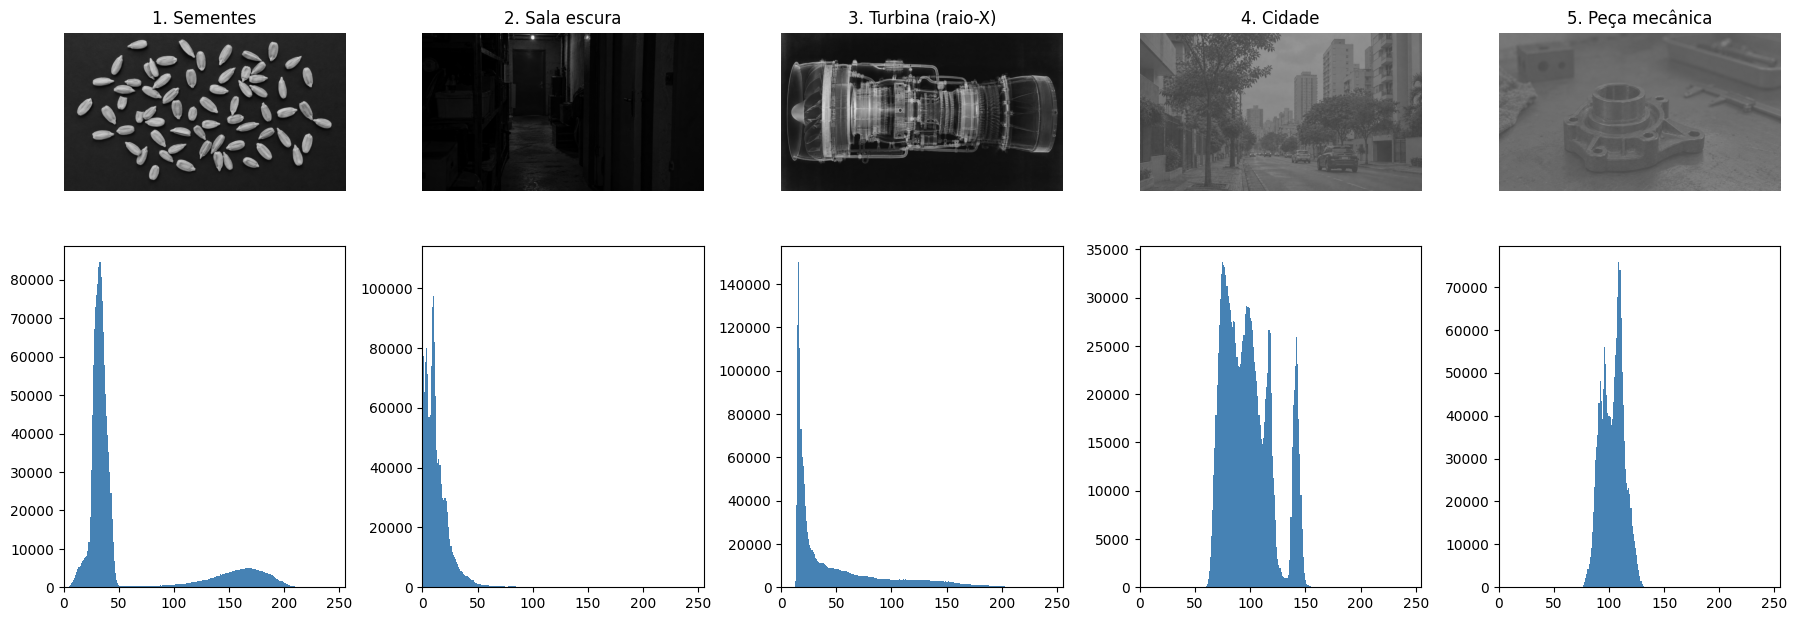

In [13]:
fig, axs = plt.subplots(2, 5, figsize=(18, 7))

ordem = ["sementes", "sala", "turbina", "cidade", "peca"]
titulos = {
    "sementes": "1. Sementes",
    "sala":     "2. Sala escura",
    "turbina":  "3. Turbina (raio-X)",
    "cidade":   "4. Cidade",
    "peca":     "5. Peça mecânica",
}

for j, nome in enumerate(ordem):
    gray = imagens_gray[nome]
    axs[0, j].imshow(gray, cmap="gray", vmin=0, vmax=255)
    axs[0, j].set_title(titulos[nome])
    axs[0, j].axis("off")

    plot_histograma(calcular_histograma(gray), "", ax=axs[1, j])
    axs[1, j].set_xlabel("")
    axs[1, j].set_ylabel("")

plt.tight_layout()
plt.show()

---
## Caso 1 - Sementes

**Diagnóstico.** Histograma bimodal quase perfeito: um pico enorme colado no 0 (fundo preto uniforme) e um segundo agrupamento largo entre 130 e 220 (as sementes). Praticamente nada entre 40 e 100. Não é problema de exposição - é uma imagem que pede segmentação: separar objeto de fundo para depois contar, medir área etc.

**Técnica/parâmetros.** Limiarização com T=70. O vale entre os dois modos fica na faixa de 60–70, então qualquer T por ali resolve. Otsu também funcionaria, mas com T fixo o critério fica mais explícito para justificar.

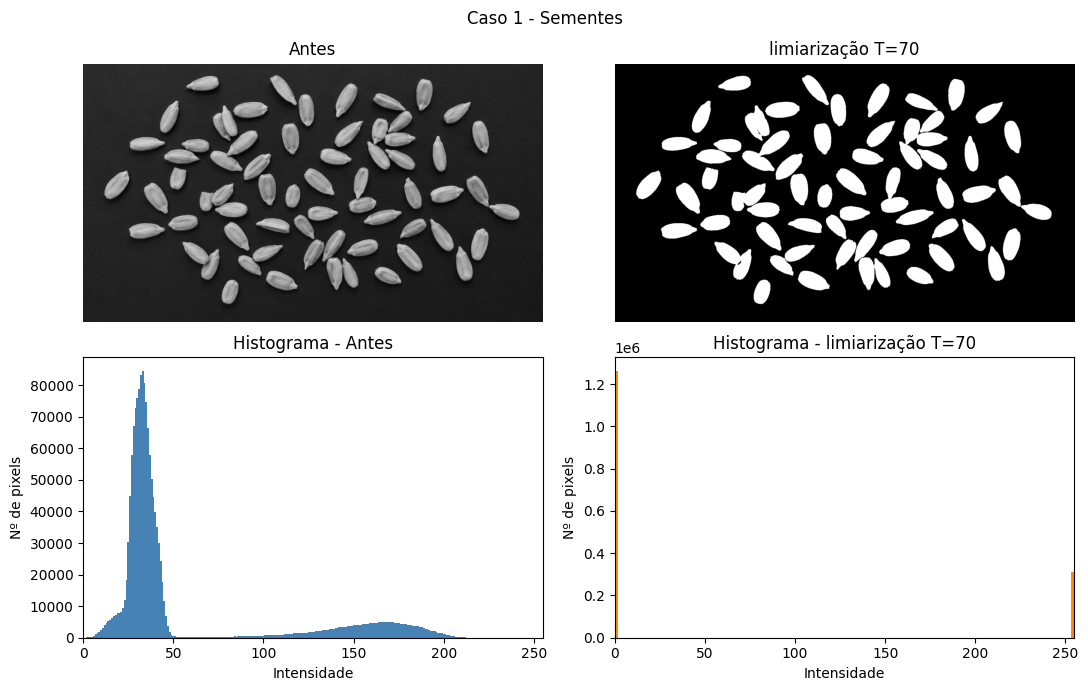

antes:  {'media': 56.86, 'std': 51.2, 'min': 0, 'max': 221, '%baixa_0_63': 80.2, '%media_64_191': 18.4, '%alta_192_255': 1.4}
depois: {'media': 50.2, 'std': 101.39, 'min': 0, 'max': 255, '%baixa_0_63': 80.3, '%media_64_191': 0.0, '%alta_192_255': 19.7}


In [14]:
gray_sementes = imagens_gray["sementes"]

T_sementes = 70
sementes_bin = limiarizar(gray_sementes, T_sementes)

mostrar_antes_depois(gray_sementes, sementes_bin, "Antes", f"limiarização T={T_sementes}",
                     "Caso 1 - Sementes", largura_depois=4)

print("antes: ", estatisticas_faixas(gray_sementes))
print("depois:", estatisticas_faixas(sementes_bin))

**Justificativa.** O histograma resultante mostra apenas duas barras (0 e 255), o esperado. As sementes ficam brancas sobre fundo preto sem vazamento, porque o vale entre os modos era largo. Bom ponto de partida para etapas seguintes de contagem ou medição de área via `connectedComponents`.

---
## Caso 2 - Sala escura

**Diagnóstico.** Mean 12, std 12, e 98% dos pixels caem entre 0 e 63. Ambiente muito escuro, com um único ponto de luz ao fundo. Há informação (max chega a 243), mas está toda espremida na base do histograma.

**Técnica/parâmetros.** Correção Gamma com γ=0.35. A expansão de contraste seria uma primeira tentativa natural, mas praticamente não muda nada aqui: como min≈0 e max≈243, os extremos já estão ocupados, o problema é a distribuição, não a faixa. Gamma resolve melhor por ser não-linear (comprime tons altos, estica tons baixos).

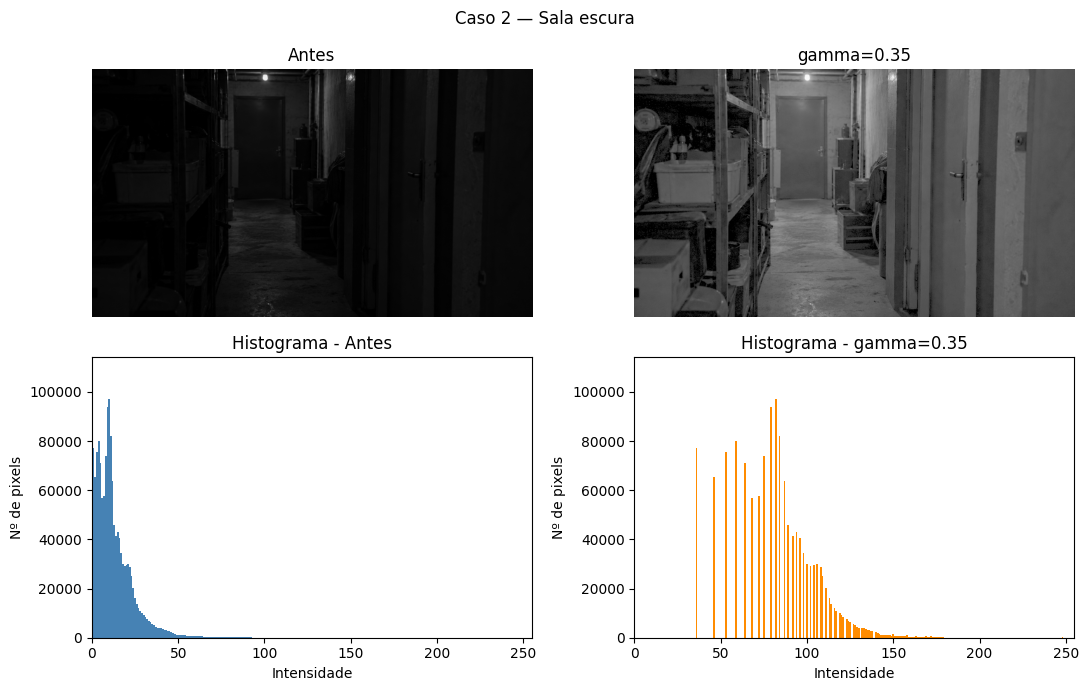

antes:  {'media': 12.33, 'std': 12.14, 'min': 0, 'max': 243, '%baixa_0_63': 99.4, '%media_64_191': 0.6, '%alta_192_255': 0.0}
depois: {'media': 77.49, 'std': 32.26, 'min': 0, 'max': 250, '%baixa_0_63': 25.8, '%media_64_191': 74.1, '%alta_192_255': 0.1}


In [15]:
gray_sala = imagens_gray["sala"]

gamma_sala = 0.35
sala_corrigida = corrigir_gamma(gray_sala, gamma_sala)

mostrar_antes_depois(gray_sala, sala_corrigida, "Antes", f"gamma={gamma_sala}", "Caso 2 — Sala escura")

print("antes: ", estatisticas_faixas(gray_sala))
print("depois:", estatisticas_faixas(sala_corrigida))

**Justificativa.** Após o gamma, as prateleiras, a porta do fundo e o corredor inteiro passam a ser visíveis. O histograma se espalha pela faixa de 0 até ~200 e a mean sobe de ~12 para bem mais alto. O custo é o ruído: como o gamma estica muito os tons baixos, variação de sensor vira granulado. Aceitável quando o objetivo é enxergar conteúdo.

---
## Caso 3 - Turbina

**Diagnóstico.** Radiografia de uma turbina. Fundo preto puro (0) domina, e as estruturas internas aparecem em tons claros, é o formato padrão de apresentação de raio-X. Histograma com pico enorme colado no 0 (fundo) e distribuição espalhada de ~20 a 230 (a peça).

**Técnica/parâmetros.** Negativo digital (255 - I). Não é correção de exposição, é escolha de apresentação: inverter para o formato "positivo", fundo branco, peça escura. Nesse formato o olho humano discrimina melhor detalhe fino de contorno.

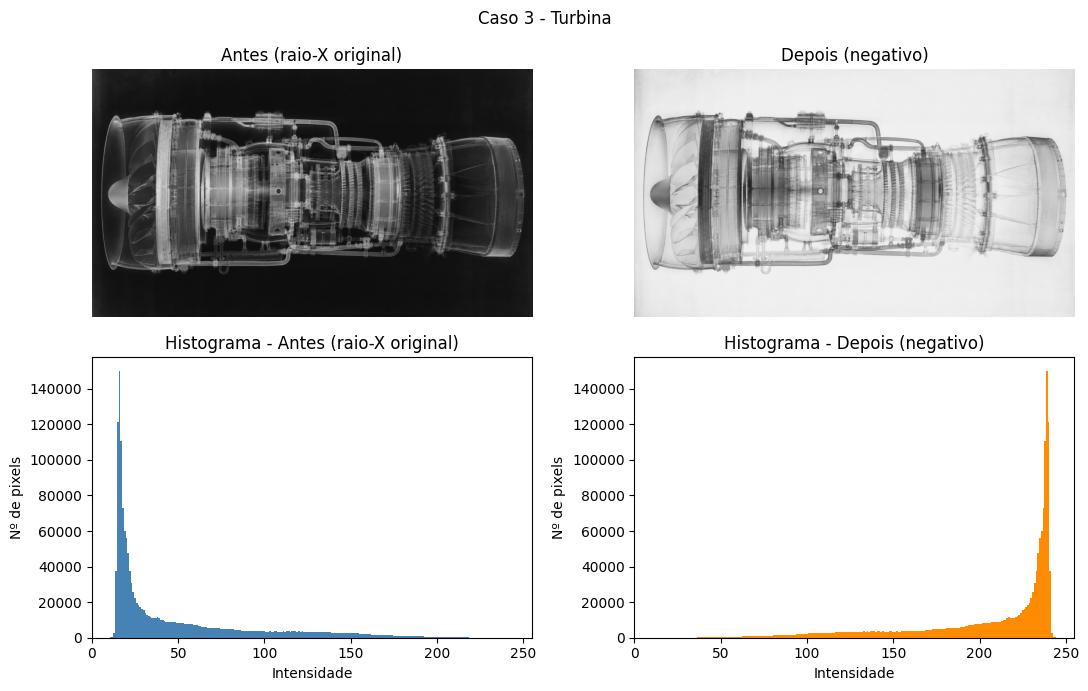

antes:  {'media': 48.58, 'std': 44.15, 'min': 4, 'max': 230, '%baixa_0_63': 74.2, '%media_64_191': 25.2, '%alta_192_255': 0.6}
depois: {'media': 206.42, 'std': 44.15, 'min': 25, 'max': 251, '%baixa_0_63': 0.6, '%media_64_191': 25.2, '%alta_192_255': 74.2}


In [16]:
gray_turbina = imagens_gray["turbina"]

turbina_negativa = negativo(gray_turbina)

mostrar_antes_depois(gray_turbina, turbina_negativa, "Antes (raio-X original)", "Depois (negativo)", "Caso 3 - Turbina")

print("antes: ", estatisticas_faixas(gray_turbina))
print("depois:", estatisticas_faixas(turbina_negativa))

**Justificativa.** O histograma inverte espelhado, o pico que estava no 0 vai para 255 (fundo virou branco) e a cauda migra para a esquerda. Mean vai de ~49 para ~206 (255 - 49 = 206, bate). Mesma informação, apresentação mais legível: pás, anéis e tubulação ficam com contorno escuro nítido sobre fundo branco.

---
## Caso 4 - Cidade

**Diagnóstico.** Foto de rua em dia nublado. Min=57, max=218, sem preto real nem branco real. O histograma é um monte estreito centrado por volta de 100, sem caudas nos extremos. Padrão "foto lavada" clássico: sem sombra profunda, sem highlight. Informação toda ali, mas espremida em ~160 dos 256 níveis possíveis.

**Técnica/parâmetros.** Expansão de contraste linear com L=57 e H=218 (os próprios extremos da imagem). O valor 57 vira 0, o 218 vira 255, o resto interpolado. Não perde nem inventa informação, só reescala.

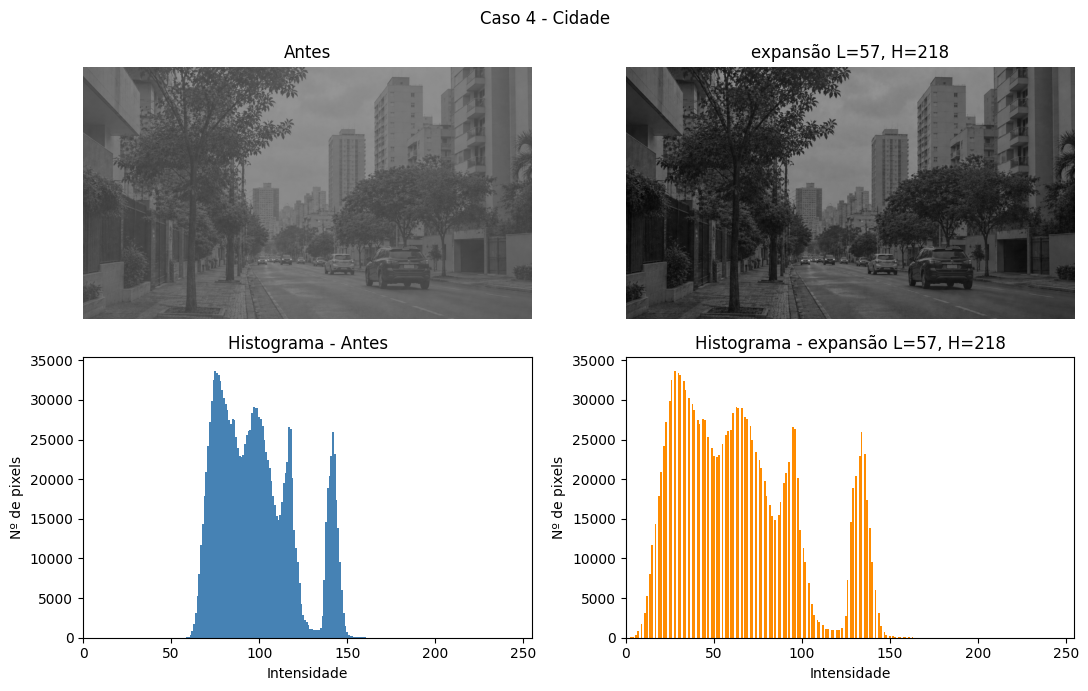

antes:  {'media': 98.76, 'std': 21.95, 'min': 57, 'max': 218, '%baixa_0_63': 0.2, '%media_64_191': 99.8, '%alta_192_255': 0.0}
depois: {'media': 65.67, 'std': 34.76, 'min': 0, 'max': 255, '%baixa_0_63': 53.2, '%media_64_191': 46.8, '%alta_192_255': 0.0}


In [17]:
gray_cidade = imagens_gray["cidade"]

L_cidade, H_cidade = 57, 218
cidade_corrigida = expandir_contraste(gray_cidade, L_cidade, H_cidade)

mostrar_antes_depois(gray_cidade, cidade_corrigida, "Antes", f"expansão L={L_cidade}, H={H_cidade}", "Caso 4 - Cidade")

print("antes: ", estatisticas_faixas(gray_cidade))
print("depois:", estatisticas_faixas(cidade_corrigida))

**Justificativa.** O histograma passa a ocupar toda a faixa 0–255 e a imagem ganha o contraste que faltava: os prédios do fundo se definem, o carro preto vira preto de verdade. O resultado tem "buracos" no histograma (barras faltando em algumas intensidades), esperado, porque 161 valores originais foram espalhados em 256 posições.

---
## Caso 5 - Peça mecânica

**Diagnóstico.** Caso mais extremo de faixa comprimida do conjunto: min=75, max=141, std=10. A imagem inteira mora em uma faixa de apenas 66 níveis. Visualmente, parece haver uma neblina cinza aplicada por cima, nem peça, nem pano, nem fundo têm contraste entre si.

**Técnica/parâmetros.** Equalização de histograma. Uma expansão de contraste também esticaria os extremos, mas a distribuição interna também é irregular (vários picos estreitos concentrados). A equalização redistribui a densidade para aproximar cada faixa a uma mesma quantidade de pixels, maximizando o contraste global.

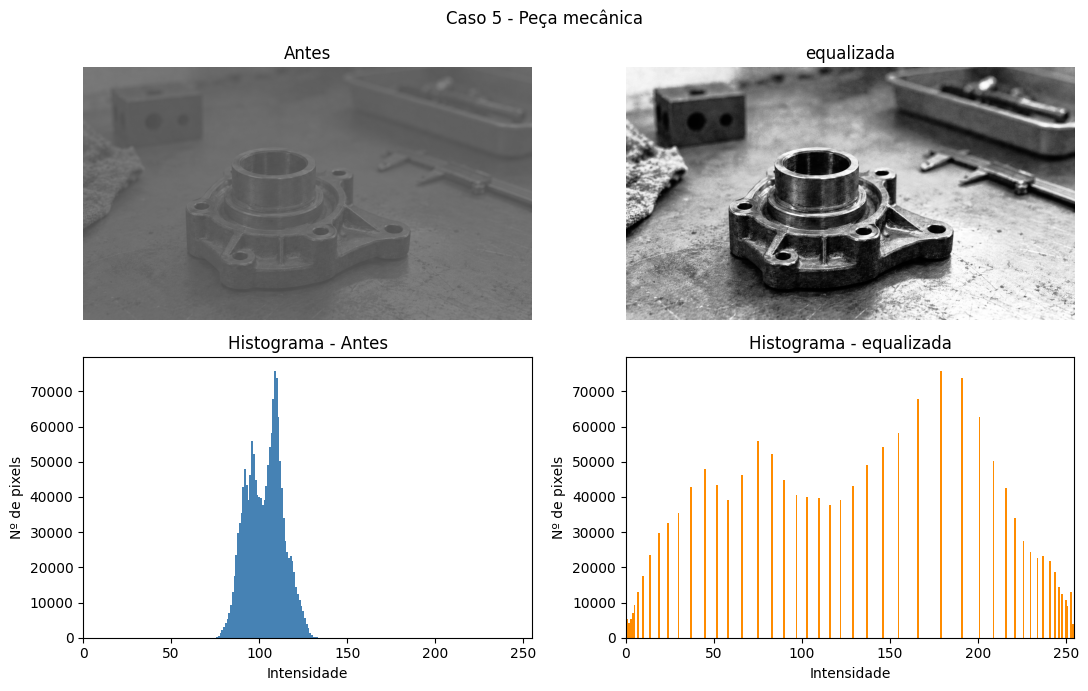

antes:  {'media': 103.33, 'std': 10.18, 'min': 75, 'max': 141, '%baixa_0_63': 0.0, '%media_64_191': 100.0, '%alta_192_255': 0.0}
depois: {'media': 131.09, 'std': 73.73, 'min': 0, 'max': 255, '%baixa_0_63': 22.8, '%media_64_191': 52.0, '%alta_192_255': 25.2}


In [18]:
gray_peca = imagens_gray["peca"]

peca_corrigida = equalizar(gray_peca)

mostrar_antes_depois(gray_peca, peca_corrigida, "Antes", "equalizada", "Caso 5 - Peça mecânica")

print("antes: ", estatisticas_faixas(gray_peca))
print("depois:", estatisticas_faixas(peca_corrigida))

**Justificativa.** A peça salta para frente: textura fundida da superfície, furos bem marcados, objetos desfocados do fundo com forma. O histograma equalizado fica no formato "esparso" típico (barras isoladas espalhadas), porque a equalização é discreta. Tons do fundo, antes parecidos, ficam artificialmente diferentes, aceitável em inspeção de peça, cujo foco é a peça.

---
## Quantização - Turbina em 16, 8 e 4 níveis

Escolha da turbina para essa parte: entre as 5, é a que tem mais variação tonal fina (pás, cilindros translúcidos, densidade da tubulação), então é onde a perda por quantização aparece primeiro. Em imagem tipo "sementes" (praticamente binária) a quantização em 4 níveis quase não altera nada.

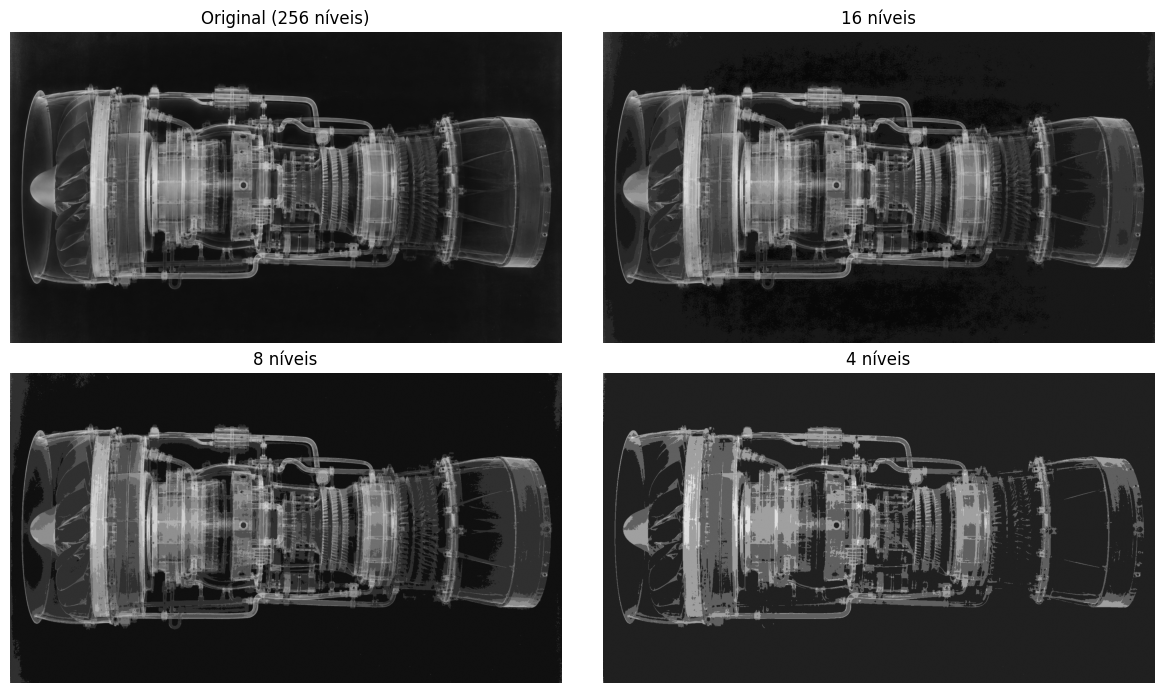

In [19]:
base_quant = gray_turbina

turbina_16 = quantizar(base_quant, 16)
turbina_8  = quantizar(base_quant, 8)
turbina_4  = quantizar(base_quant, 4)

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
axs[0, 0].imshow(base_quant, cmap="gray", vmin=0, vmax=255); axs[0, 0].set_title("Original (256 níveis)"); axs[0, 0].axis("off")
axs[0, 1].imshow(turbina_16, cmap="gray", vmin=0, vmax=255); axs[0, 1].set_title("16 níveis");            axs[0, 1].axis("off")
axs[1, 0].imshow(turbina_8,  cmap="gray", vmin=0, vmax=255); axs[1, 0].set_title("8 níveis");             axs[1, 0].axis("off")
axs[1, 1].imshow(turbina_4,  cmap="gray", vmin=0, vmax=255); axs[1, 1].set_title("4 níveis");             axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

**Comentário.** Com **16 níveis** não há diferença perceptível a olho nu, o cinza contínuo das pás permanece suave e o detalhe fino da tubulação continua legível. Com **8 níveis** aparece o *banding* (falso contorno) nas regiões de transição suave, principalmente nas pás grandes da frente e nos cilindros translúcidos, onde antes havia gradiente contínuo. Com **4 níveis** a perda fica óbvia: sobram praticamente preto, dois cinzas e branco; pás finas do fundo somem e a imagem vira quase um pôster estilizado.

A perda começa a ser notada em **8 níveis** e se torna claramente perceptível em **4 níveis**.